In [76]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

# 한글 폰트 자동 설정(환경에 따라 없으면 무시)
for _font in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    try:
        plt.rcParams["font.family"] = _font
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False


def find_browser_automation_root(start: Path | None = None) -> Path:
    base = (start or Path.cwd()).resolve()
    for current in [base, *base.parents]:
        if current.name == "browser_automation" and (current / "collector_api").exists():
            return current
    raise FileNotFoundError("browser_automation 루트를 찾지 못했습니다.")


ROOT = find_browser_automation_root()
TRIAL_DIR = ROOT / "collector_api" / "data" / "trials"
FEATURE_MD = ROOT / "analysis" / "feature.md"
print("ROOT:", ROOT)
print("TRIAL_DIR:", TRIAL_DIR)


def load_feature_name_map_ko(path: Path) -> dict[str, str]:
    """analysis/feature.md에서 feature -> 한글 표시명(짧은 라벨) 추출."""
    if not path.exists():
        return {}

    mapping: dict[str, str] = {}
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line.startswith("|"):
            continue
        parts = [p.strip() for p in line.strip("|").split("|")]
        if len(parts) < 2:
            continue
        feature = parts[0]
        if not (feature.startswith("`") and feature.endswith("`")):
            continue
        feature_key = feature.strip("`")
        feature_ko = parts[1]
        if feature_key and feature_ko:
            mapping[feature_key] = feature_ko
    return mapping


FEATURE_NAME_KO = load_feature_name_map_ko(FEATURE_MD)

# feature.md에 없는 파생 컬럼은 여기서 한글명 보강(짧게)
FEATURE_NAME_KO.update(
    {
        "pre_click_path_300ms_total_distance_px": "300ms 이동거리",
        "pre_click_path_300ms_straightness": "300ms 직선성",
        "pre_click_path_500ms_total_distance_px": "500ms 이동거리",
        "pre_click_path_500ms_straightness": "500ms 직선성",
    }
)

print("loaded feature ko names:", len(FEATURE_NAME_KO), "from", FEATURE_MD)


ROOT: C:\Users\SSAFY\Desktop\ws\01_main\S14P31A203\services\ai\macro\browser_automation
TRIAL_DIR: C:\Users\SSAFY\Desktop\ws\01_main\S14P31A203\services\ai\macro\browser_automation\collector_api\data\trials
loaded feature ko names: 51 from C:\Users\SSAFY\Desktop\ws\01_main\S14P31A203\services\ai\macro\browser_automation\analysis\feature.md


In [77]:
# feature.md 기반 3그룹

CLICK_FEATURES = [
    "time_to_first_click_ms",
    "time_from_element_visible_to_click_ms",
    "time_from_element_clickable_to_click_ms",
    "inter_click_interval_ms",
    "click_sequence_consistency_score",
    "click_position_repeat_rate",
    "click_offset_from_element_center_px",
    "click_offset_variance_px",
    "double_click_rate",
    "misclick_rate",
    "reclick_rate",
    "pre_click_mousemove_count",
    "pre_click_hover_time_ms",
    "pre_click_scroll_flag",
    "immediate_post_render_click_rate",
]

MOUSE_FEATURES = [
    "mouse_total_travel_distance_px",
    "mouse_avg_speed_px_per_ms",
    "mouse_max_speed_px_per_ms",
    "mouse_speed_change_mean",
    "mouse_acceleration_mean",
    "mouse_jerk_mean",
    "mouse_path_straightness_score",
    "mouse_path_curvature_mean",
    "mouse_direction_change_count",
    "mouse_overshoot_flag",
    "mouse_hover_dwell_time_ms",
    "mouse_stop_segment_count",
    "mousemove_event_rate",
    "inter_element_move_interval_std_ms",
    "edge_or_fixed_point_visit_rate",
    # 문자열 요약값에서 파생한 numeric
    "pre_click_path_300ms_total_distance_px",
    "pre_click_path_300ms_straightness",
    "pre_click_path_500ms_total_distance_px",
    "pre_click_path_500ms_straightness",
]

KEYBOARD_FEATURES = [
    "time_to_first_keydown_ms",
    "inter_key_interval_ms_mean",
    "inter_key_interval_ms_std",
    "keydown_to_keyup_ms_mean",
    "typing_total_duration_ms",
    "typing_speed_cps",
    "backspace_rate",
    "correction_count",
    "paste_flag",
    "focus_to_submit_ms",
]

FEATURE_GROUPS = {
    "click": CLICK_FEATURES,
    "mouse": MOUSE_FEATURES,
    "keyboard": KEYBOARD_FEATURES,
}

{k: len(v) for k, v in FEATURE_GROUPS.items()}


{'click': 15, 'mouse': 19, 'keyboard': 10}

In [78]:
def extract_label(payload: dict) -> str | None:
    label = payload.get("label")
    if isinstance(label, str):
        return label
    summary = payload.get("summary")
    if isinstance(summary, dict) and isinstance(summary.get("label"), str):
        return summary.get("label")
    return None


def load_trials(trial_dir: Path, label: str = "human") -> tuple[pd.DataFrame, dict[str, int]]:
    rows: list[dict] = []
    counters = {"total": 0, "kept": 0, "skipped_other": 0, "no_label": 0}

    for path in sorted(trial_dir.glob("trial_*.json")):
        counters["total"] += 1
        payload = json.loads(path.read_text(encoding="utf-8"))
        lb = extract_label(payload)
        if lb is None:
            counters["no_label"] += 1
            continue
        if lb != label:
            counters["skipped_other"] += 1
            continue

        counters["kept"] += 1
        trial_id = int(payload.get("trialId") or payload.get("trial_id") or 0)
        summary = payload.get("summary") or {}
        metrics = payload.get("metrics") or {}

        row = {
            "trial_id": trial_id,
            "label": lb,
            "event_count": len(payload.get("eventRows", []) or []),
            "window_count": len(payload.get("windowRows", []) or []),
        }
        if isinstance(summary, dict):
            row.update(summary)
        if isinstance(metrics, dict):
            row.update(metrics)
        rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty and "trial_id" in df.columns:
        df = df.sort_values("trial_id").reset_index(drop=True)
    return df, counters


df, counters = load_trials(TRIAL_DIR, label="human")
print(counters)
display(df.head())


{'total': 324, 'kept': 160, 'skipped_other': 164, 'no_label': 0}


,trial_id,label,event_count,window_count,stage,durationMs,clickCount,eventCount,windowCount,selectedSeats,time_to_first_click_ms,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,inter_click_interval_ms,click_sequence_consistency_score,click_position_repeat_rate,click_offset_from_element_center_px,click_offset_variance_px,double_click_rate,misclick_rate,reclick_rate,pre_click_mousemove_count,pre_click_hover_time_ms,pre_click_scroll_flag,immediate_post_render_click_rate,mouse_total_travel_distance_px,mouse_avg_speed_px_per_ms,mouse_max_speed_px_per_ms,mouse_speed_change_mean,mouse_acceleration_mean,mouse_jerk_mean,mouse_path_straightness_score,mouse_path_curvature_mean,mouse_direction_change_count,mouse_overshoot_flag,mouse_hover_dwell_time_ms,mouse_stop_segment_count,mousemove_event_rate,pre_click_mouse_path_pattern_300ms,pre_click_mouse_path_pattern_500ms,inter_element_move_interval_std_ms,edge_or_fixed_point_visit_rate,time_to_first_keydown_ms,inter_key_interval_ms_mean,inter_key_interval_ms_std,keydown_to_keyup_ms_mean,typing_total_duration_ms,typing_speed_cps,backspace_rate,correction_count,paste_flag,focus_to_submit_ms
0,2,human,323,26,confirmed,6458.4,9,323,26,"[B5, B4]",851.7,1513.637500,1513.637500,700.800000,0.875000,0.0,28.493302,646.669910,0.444444,0.111111,0.111111,27.444444,246.944444,0.0,0.0,2828.306989,0.437927,10.561944,0.445123,0.052016,0.004934,0.358283,0.206629,58,0,210.584000,20,46.296296,40.9px | straight 0.93,814.6px | straight 0.97,694.574215,0.0,558.8,192.15,131.387845,117.814286,1152.9,6.071645,0.0,0,0,2887.7
1,3,human,322,23,confirmed,5969.8,7,322,23,"[B4, B5]",951.6,1510.433333,1510.433333,836.316667,0.833333,0.0,26.679236,122.389226,0.285714,0.142857,0.000000,33.000000,220.442857,0.0,0.0,1969.649553,0.329936,6.833317,0.267882,0.031645,0.003265,0.449383,0.248568,74,0,199.658333,12,50.587959,133.3px | straight 0.97,702.2px | straight 0.98,704.293103,0.0,622.1,153.96,56.480779,127.083333,769.8,7.794232,0.0,0,0,2363.3
2,4,human,253,23,confirmed,5535.6,5,253,23,"[B4, B5]",1731.0,1456.900000,1456.900000,951.050000,1.000000,0.0,45.429430,1404.299006,0.200000,0.000000,0.000000,33.400000,207.200000,0.0,0.0,1939.123226,0.350300,5.180723,0.306412,0.036340,0.003624,0.451466,0.138800,35,0,193.380000,9,42.452489,81.9px | straight 0.94,593.8px | straight 0.99,674.567448,0.0,523.9,161.58,87.159358,147.133333,807.9,7.426662,0.0,0,0,2125.2
3,5,human,276,22,confirmed,5874.0,6,276,22,"[B4, B5]",1533.5,1529.080000,1529.080000,868.060000,0.800000,0.0,29.553804,374.657158,0.333333,0.166667,0.000000,29.500000,178.900000,0.0,0.0,2085.415223,0.355025,4.651163,0.269461,0.032168,0.003403,0.428887,0.206689,47,0,175.150000,13,43.752128,92.9px | straight 0.98,626.0px | straight 0.99,726.495620,0.0,468.5,156.80,51.045117,129.183333,784.0,7.653061,0.0,0,0,2587.7
4,6,human,273,22,confirmed,5494.7,5,273,22,"[B5, B4]",1588.4,1543.140000,1543.140000,976.525000,1.000000,0.0,41.578537,470.444485,0.000000,0.000000,0.000000,23.200000,299.980000,0.0,0.0,2879.063205,0.523971,16.973684,0.542276,0.065251,0.006346,0.319944,0.197378,42,0,173.646154,16,46.408357,85.4px | straight 0.98,704.8px | straight 0.99,412.409198,0.0,493.7,104.30,44.306749,121.050000,521.5,11.505273,0.0,0,0,1720.2


In [79]:
PATH_RE = re.compile(r"(?P<dist>[-+]?\d+(\.\d+)?)px\s*\|\s*straight\s*(?P<straight>[-+]?\d+(\.\d+)?)", re.I)


def add_pre_click_path_features(df: pd.DataFrame) -> None:
    for win in [300, 500]:
        col = f"pre_click_mouse_path_pattern_{win}ms"
        if col not in df.columns:
            continue
        extracted = df[col].astype("string").str.extract(PATH_RE)
        df[f"pre_click_path_{win}ms_total_distance_px"] = pd.to_numeric(extracted["dist"], errors="coerce")
        df[f"pre_click_path_{win}ms_straightness"] = pd.to_numeric(extracted["straight"], errors="coerce")


add_pre_click_path_features(df)

for win in [300, 500]:
    a = f"pre_click_path_{win}ms_total_distance_px"
    b = f"pre_click_path_{win}ms_straightness"
    if a in df.columns:
        print(win, "ms:", a, "non-null=", int(df[a].notna().sum()), "/", len(df))
    if b in df.columns:
        print(win, "ms:", b, "non-null=", int(df[b].notna().sum()), "/", len(df))


300 ms: pre_click_path_300ms_total_distance_px non-null= 146 / 160
300 ms: pre_click_path_300ms_straightness non-null= 146 / 160
500 ms: pre_click_path_500ms_total_distance_px non-null= 156 / 160
500 ms: pre_click_path_500ms_straightness non-null= 156 / 160


In [80]:
def coerce_numeric(df: pd.DataFrame, features: list[str]) -> tuple[pd.DataFrame, list[str], list[str], list[str]]:
    existing = [f for f in features if f in df.columns]
    not_found = [f for f in features if f not in df.columns]
    frame = df[existing].apply(pd.to_numeric, errors="coerce")
    usable = [c for c in frame.columns if frame[c].notna().any()]
    dropped_all_nan = [c for c in existing if c not in usable]
    return frame[usable], usable, not_found, dropped_all_nan


def feature_stats(frame: pd.DataFrame) -> pd.DataFrame:
    n_rows = max(1, int(frame.shape[0]))
    rows = []
    for col in frame.columns:
        s = frame[col]
        non_null = s.dropna()
        rows.append(
            {
                # "feature": col,
                "feature_ko": FEATURE_NAME_KO.get(col, col),
                "count": int(non_null.shape[0]),
                "missing_rate": float(s.isna().mean()) if n_rows else np.nan,
                "mean": float(non_null.mean()) if non_null.shape[0] else np.nan,
                "min": float(non_null.min()) if non_null.shape[0] else np.nan,
                "max": float(non_null.max()) if non_null.shape[0] else np.nan,
                "var": float(non_null.var(ddof=1)) if non_null.shape[0] >= 2 else np.nan,
                "std": float(non_null.std(ddof=1)) if non_null.shape[0] >= 2 else np.nan,
            }
        )
    out = pd.DataFrame(rows)
    return out.sort_values(["missing_rate", "var"], ascending=[True, False]).reset_index(drop=True)


group_frames: dict[str, pd.DataFrame] = {}
group_features: dict[str, list[str]] = {}
stats_by_group: dict[str, pd.DataFrame] = {}

for group_name, features in FEATURE_GROUPS.items():
    frame, usable, not_found, dropped_all_nan = coerce_numeric(df, features)
    group_frames[group_name] = frame
    group_features[group_name] = usable
    stats_by_group[group_name] = feature_stats(frame)
    print(group_name, "usable:", len(usable), "/", len(features))
    if not_found:
        print("  not found:", not_found)
    if dropped_all_nan:
        print("  dropped (all NaN after numeric coerce):", dropped_all_nan)


print("\n클릭 features stats:")
display(stats_by_group["click"].head(20))
print("마우스 features stats:")
display(stats_by_group["mouse"].head(20))
print("키보드 features stats:")
display(stats_by_group["keyboard"].head(20))


click usable: 15 / 15
mouse usable: 19 / 19
keyboard usable: 10 / 10

클릭 features stats:


,feature_ko,count,missing_rate,mean,min,max,var,std
0,오차 분산,160,0.0,12729.069166,31.173682,191714.716247,1.653115e+09,40658.519508
1,노출 후 클릭,160,0.0,1832.224329,1119.720000,6103.450000,4.054748e+05,636.768997
2,활성 후 클릭,160,0.0,1832.224329,1119.720000,6103.450000,4.054748e+05,636.768997
3,첫 클릭 시간,160,0.0,1621.915000,745.100000,5950.100000,2.090383e+05,457.207038
4,클릭 간격,160,0.0,1167.738287,647.160000,2576.650000,1.281389e+05,357.964918
5,클릭 전 hover,160,0.0,253.144239,120.371429,631.183333,8.326495e+03,91.249629
6,중심 오차,160,0.0,61.981601,15.000771,300.236799,2.847090e+03,53.358126
7,클릭 전 이동 수,160,0.0,27.101471,13.000000,40.166667,2.741742e+01,5.236165
8,더블클릭 비율,160,0.0,0.233800,0.000000,0.500000,1.083839e-02,0.104108
9,즉시 클릭 비율,160,0.0,0.076803,0.000000,0.200000,8.843422e-03,0.094039


마우스 features stats:


,feature_ko,count,missing_rate,mean,min,max,var,std
0,총 이동 거리,160,0.0000,2583.859984,1597.397965,6773.917091,659826.134864,812.296827
1,이동 간격 표준편차,160,0.0000,920.615399,412.409198,2574.095837,197531.259641,444.444889
2,평균 dwell,160,0.0000,208.506366,84.116667,401.065000,3485.857879,59.041154
3,방향 전환 수,160,0.0000,56.025000,20.000000,177.000000,402.691195,20.067167
4,mousemove 빈도,160,0.0000,43.254905,25.119496,65.943979,60.167947,7.756800
5,정지 구간 수,160,0.0000,15.250000,7.000000,40.000000,23.962264,4.895127
6,최대 속도,160,0.0000,10.422780,3.932809,26.269096,18.087285,4.252915
7,오버슈트 여부,160,0.0000,0.118750,0.000000,1.000000,0.105307,0.324510
8,경로 직선성,160,0.0000,0.384146,0.145254,0.534125,0.007238,0.085078
9,속도 변화,160,0.0000,0.389055,0.234866,0.665298,0.007073,0.084101


키보드 features stats:


,feature_ko,count,missing_rate,mean,min,max,var,std
0,총 입력 시간,160,0.0,1382.857500,356.600000,11180.200000,1.843360e+06,1357.703807
1,포커스 후 확인,160,0.0,2693.134375,-3285.400000,6878.000000,1.571630e+06,1253.646836
2,첫 키 입력 시간,160,0.0,489.486250,-4822.500000,2403.300000,4.745210e+05,688.854825
3,키 간격 표준편차,160,0.0,136.777219,12.416698,1224.103056,2.050550e+04,143.197418
4,키 간격 평균,160,0.0,187.107062,71.320000,568.657143,7.482662e+03,86.502379
5,키 누름 시간,160,0.0,129.399510,89.925000,189.013333,5.287953e+02,22.995550
6,초당 입력 수,160,0.0,7.385540,2.009747,16.825575,8.137537e+00,2.852637
7,수정 횟수,160,0.0,0.787500,0.000000,16.000000,4.080346e+00,2.019987
8,백스페이스 비율,160,0.0,0.052586,0.000000,0.533333,1.103289e-02,0.105038
9,붙여넣기 여부,160,0.0,0.000000,0.000000,0.000000,0.000000e+00,0.000000


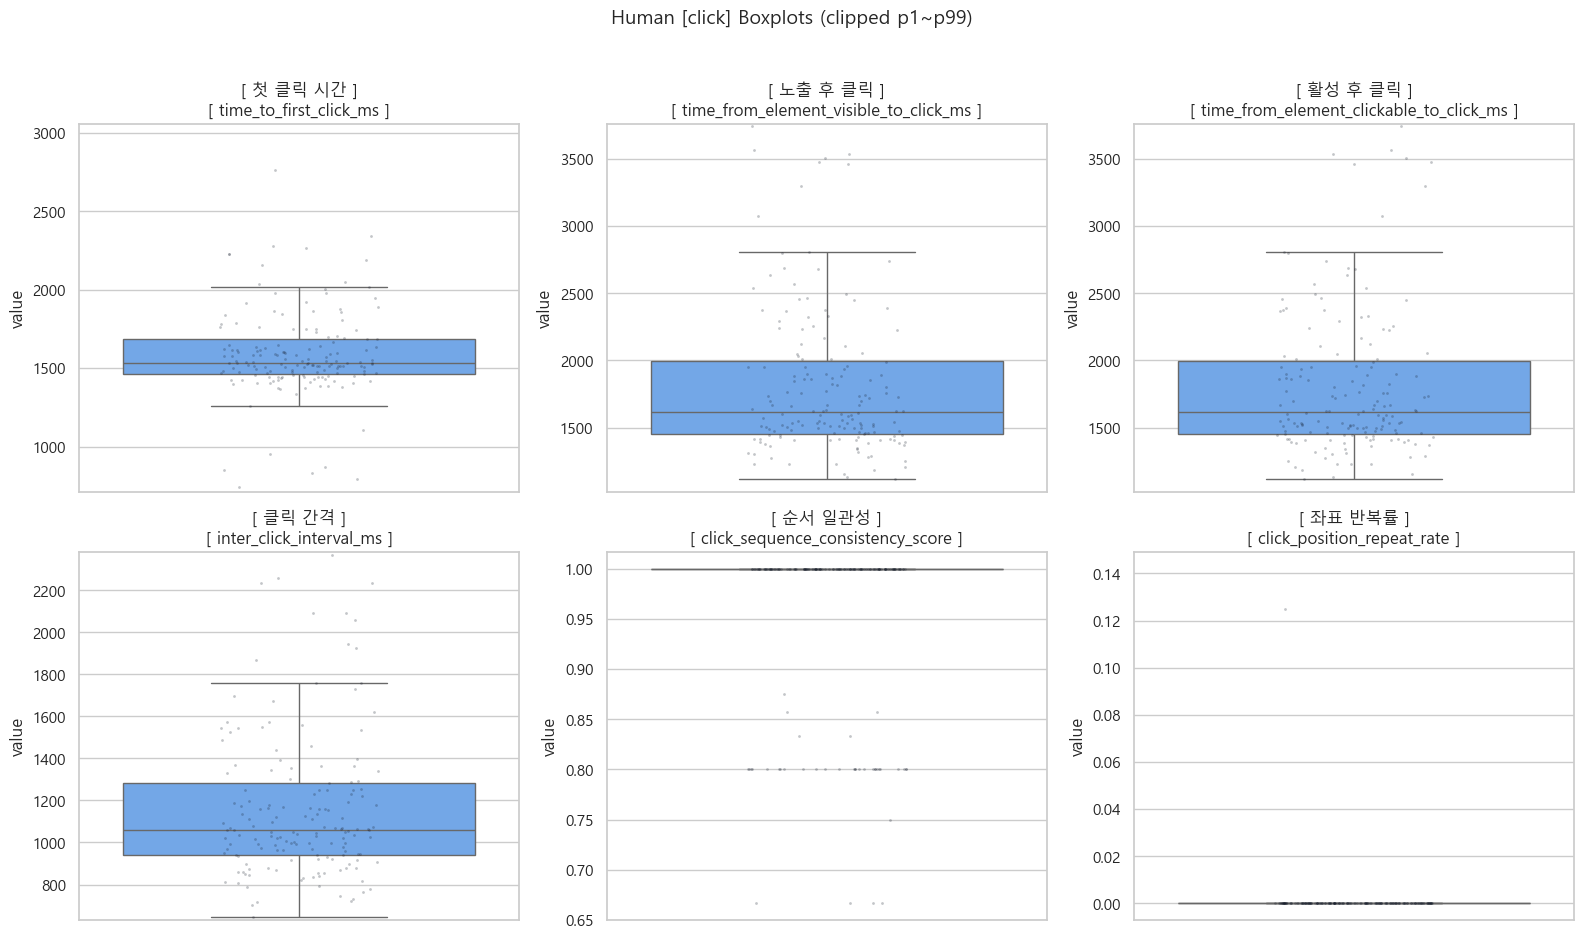

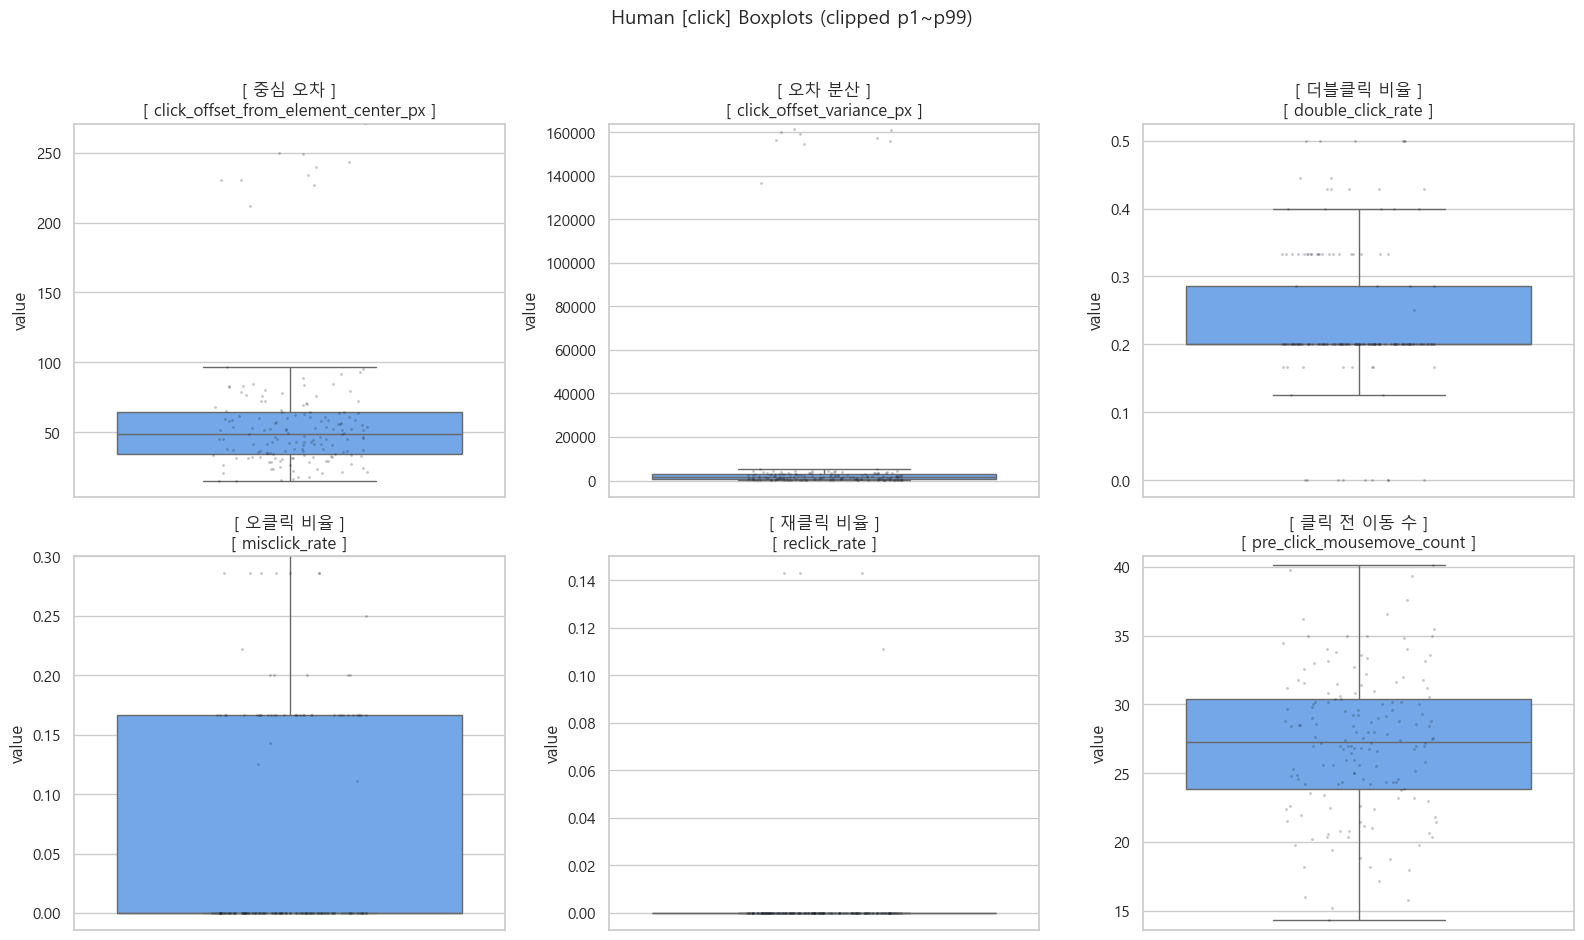

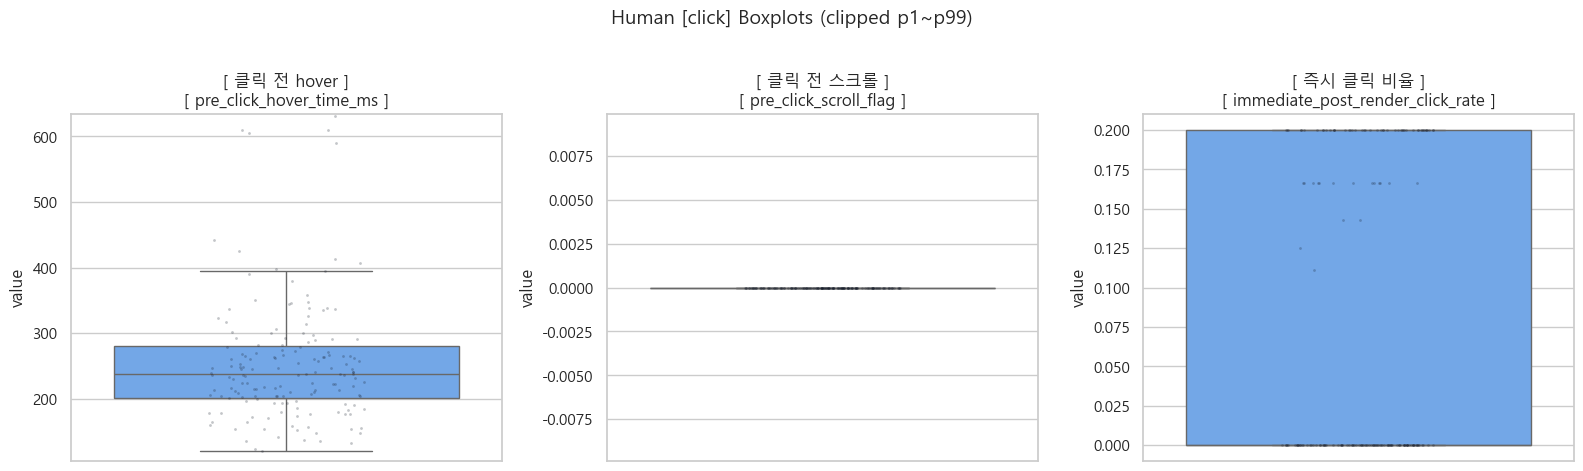

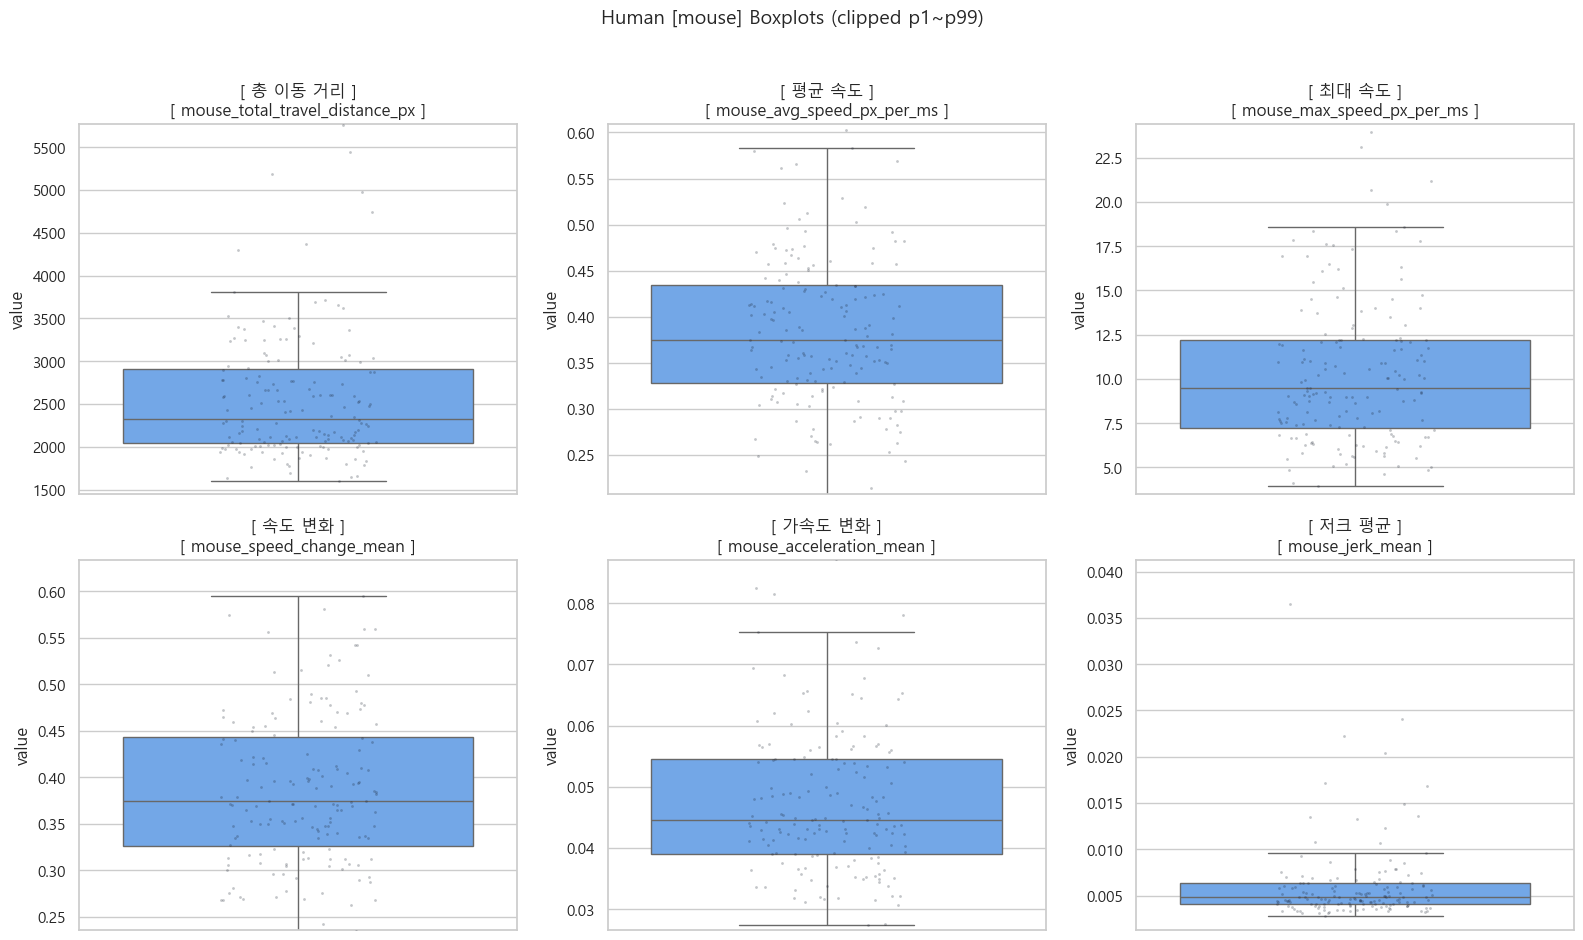

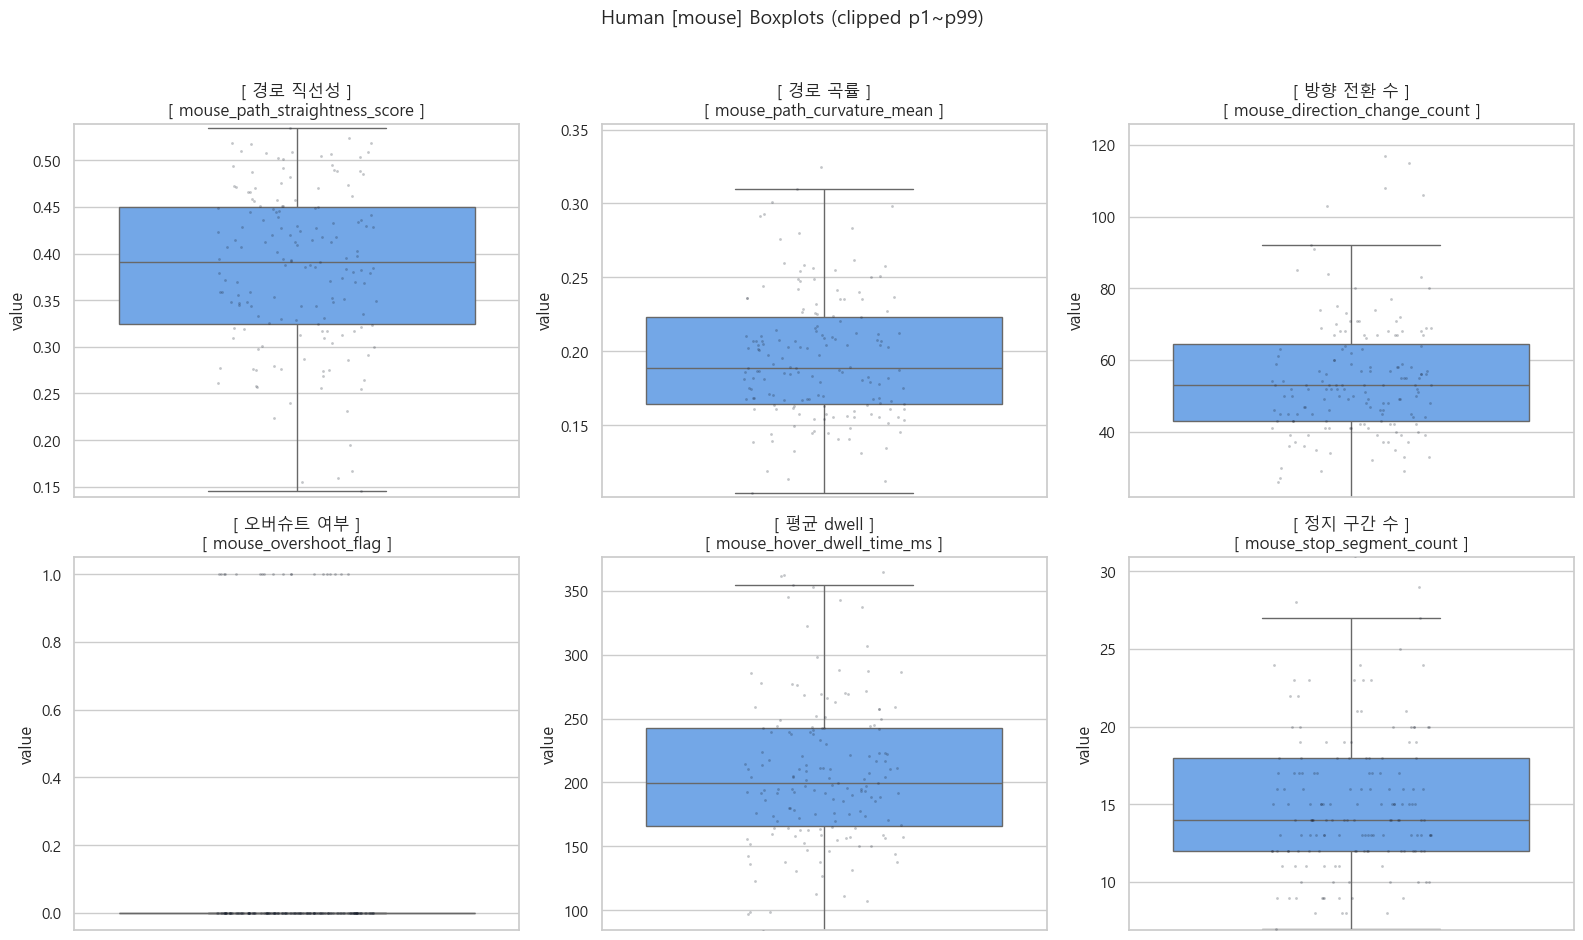

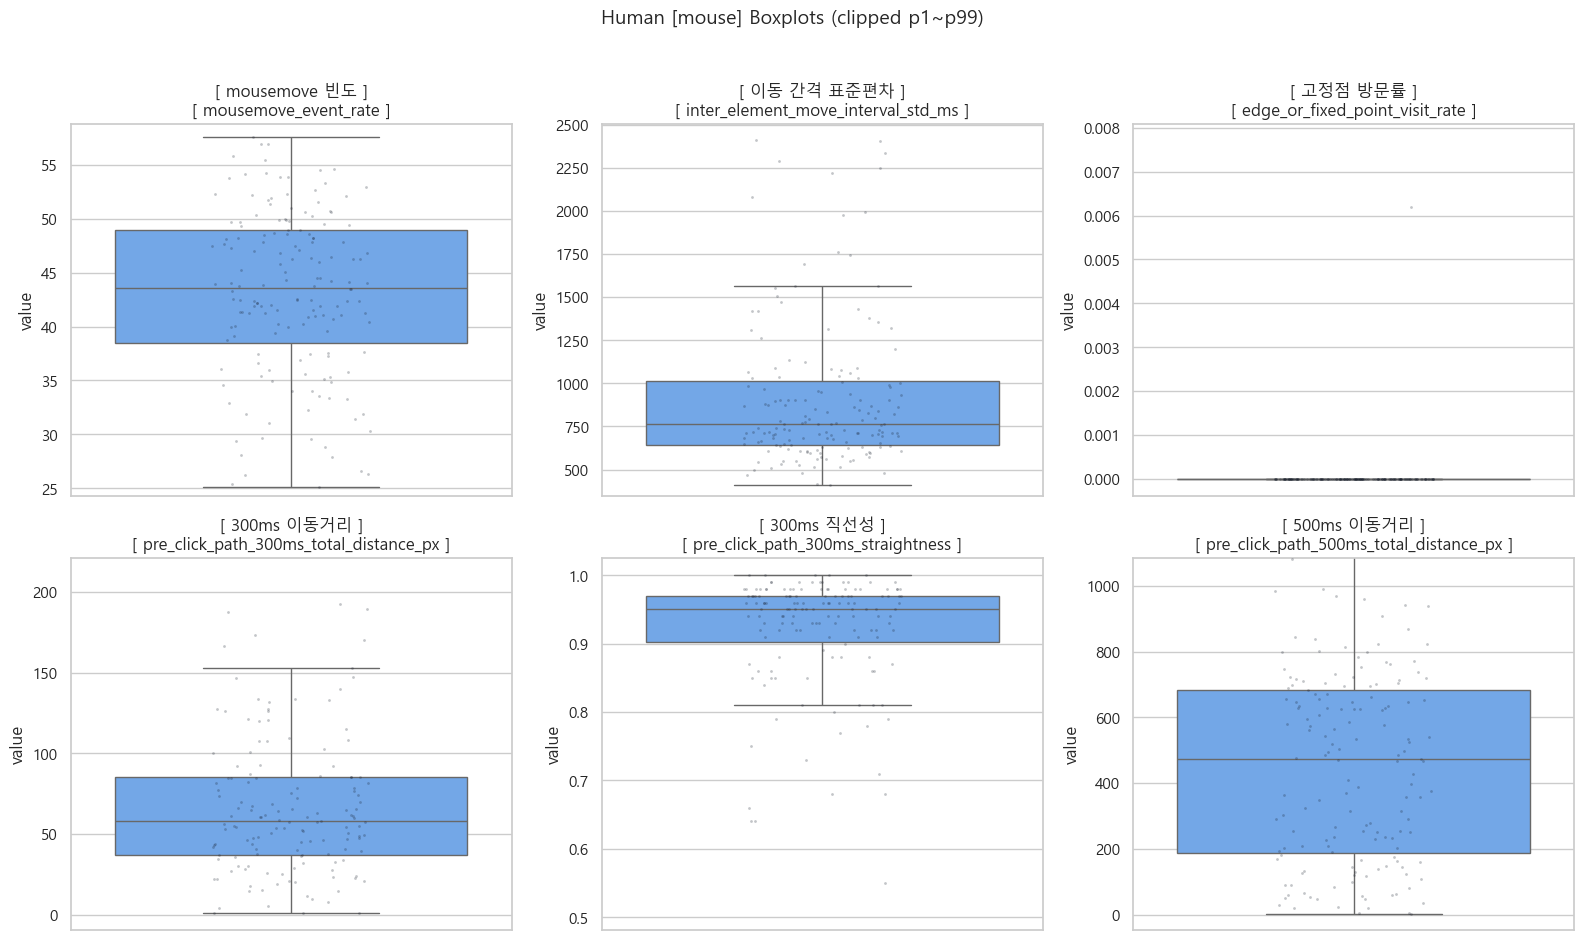

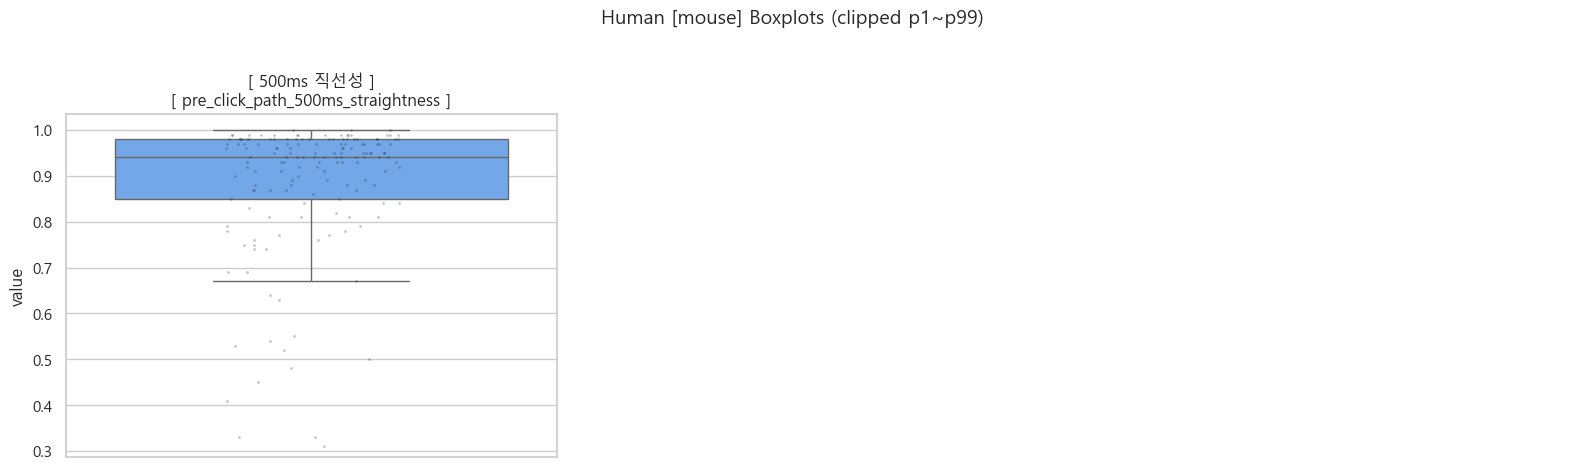

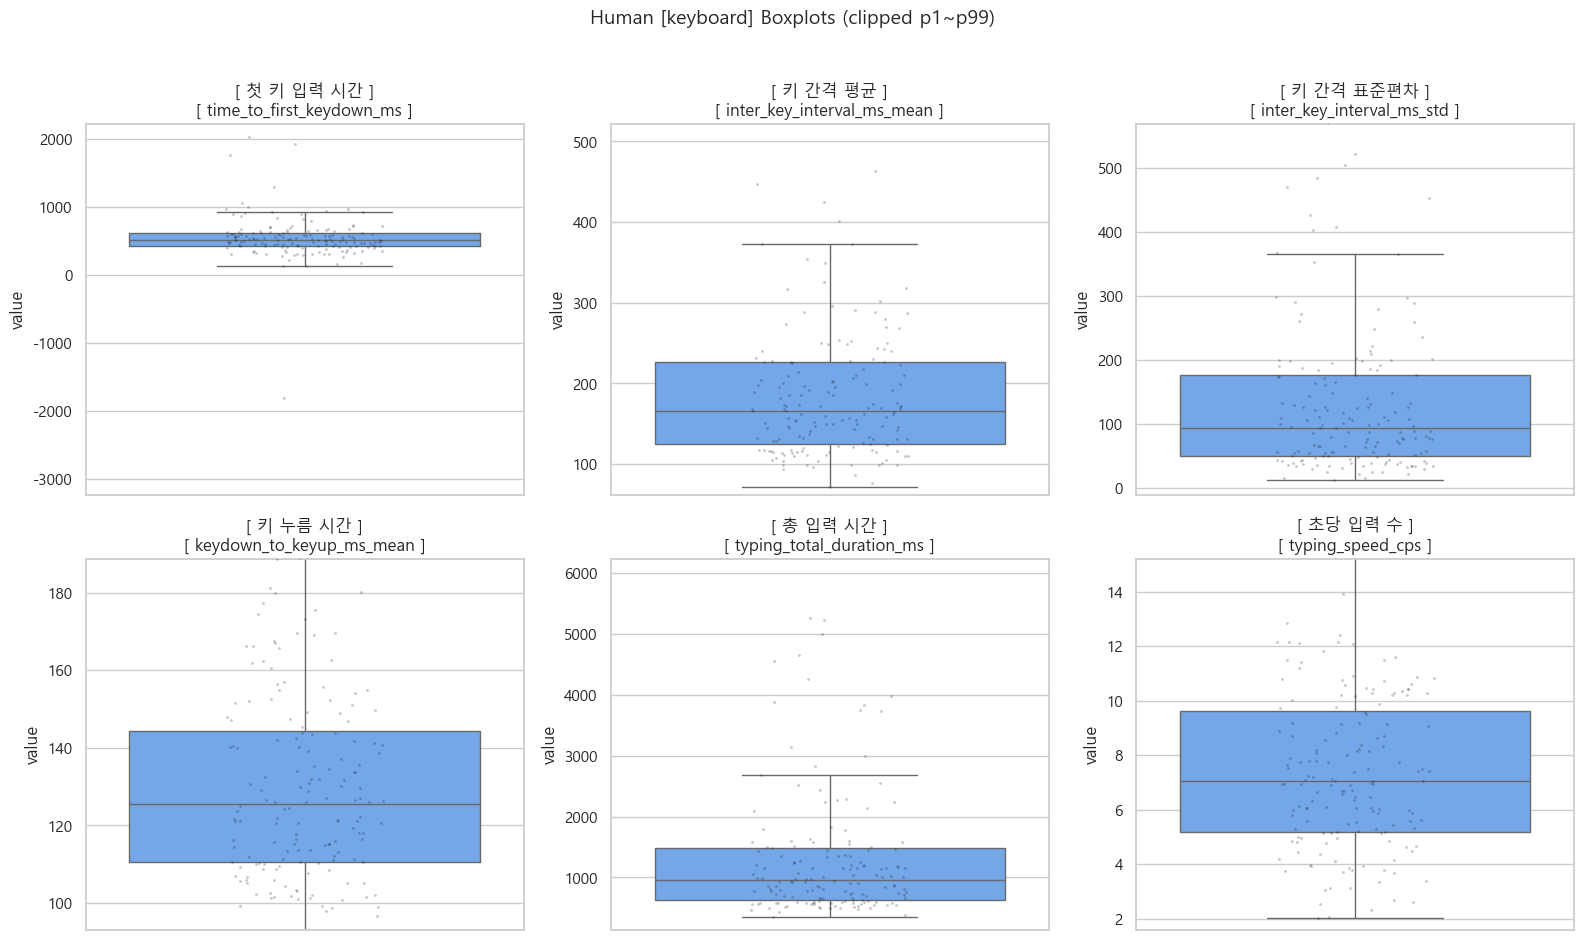

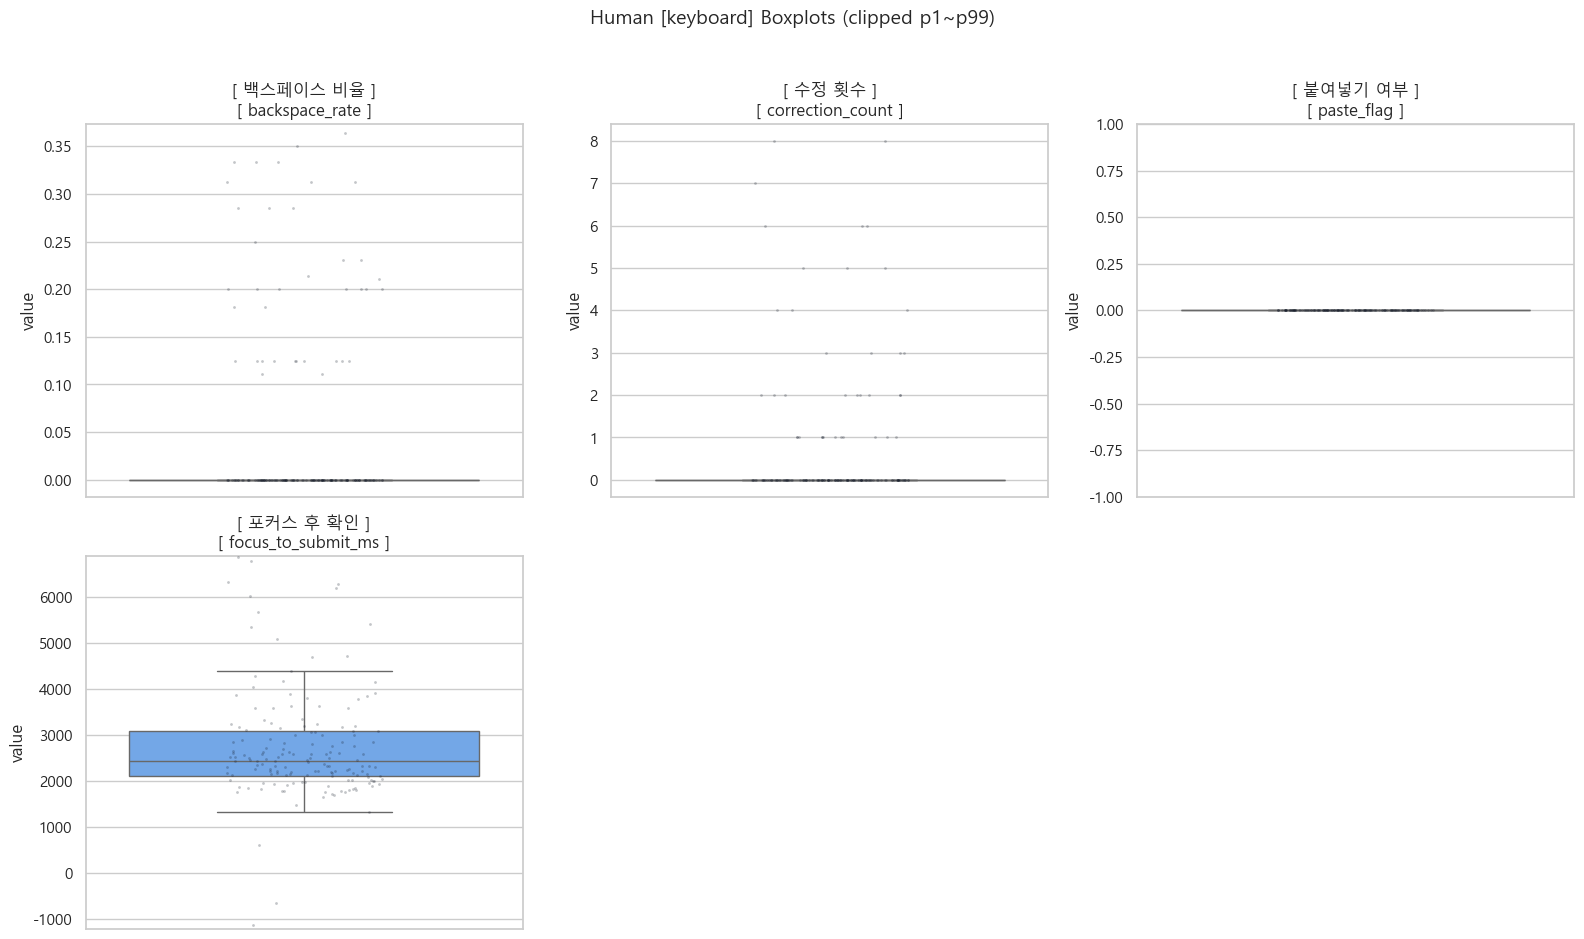

In [81]:
# 그룹별 박스플랏(원본 스케일) - outlier 영향 완화용 y축 클리핑
CLIP_Q_LOW = 0.01
CLIP_Q_HIGH = 0.99
SUBPLOT_COLS = 3
FEATURES_PER_FIG = 6


def _clip_limits(values: pd.Series, q_low: float, q_high: float) -> tuple[float, float] | None:
    values = pd.to_numeric(values, errors="coerce").dropna()
    if values.empty:
        return None

    q25 = float(values.quantile(0.25))
    q75 = float(values.quantile(0.75))
    iqr = q75 - q25

    def limits_for(ql: float, qh: float) -> tuple[float, float] | None:
        lo = float(values.quantile(ql))
        hi = float(values.quantile(qh))
        if not np.isfinite(lo) or not np.isfinite(hi):
            return None
        if hi <= lo:
            med = float(values.median())
            std = float(values.std(ddof=1)) if values.shape[0] >= 2 else 0.0
            pad = std if std > 0 else (1.0 if med == 0 else abs(med) * 0.05)
            return (med - pad, med + pad)
        pad = (hi - lo) * 0.05
        return (lo - pad, hi + pad)

    base = limits_for(q_low, q_high)
    if base is None:
        return None

    lo, hi = base
    span = hi - lo
    if iqr <= 0:
        return (lo, hi)

    ratio = span / max(iqr, 1e-9)
    if ratio > 60:
        tightened = limits_for(0.05, 0.95)
        if tightened is not None:
            lo, hi = tightened
            span = hi - lo
            ratio = span / max(iqr, 1e-9)
    if ratio > 90:
        tightened = limits_for(0.1, 0.9)
        if tightened is not None:
            lo, hi = tightened

    return (lo, hi)


def plot_group_boxplots(frame: pd.DataFrame, group_name: str) -> None:
    cols = list(frame.columns)
    if not cols:
        print("skip boxplot:", group_name)
        return

    for start in range(0, len(cols), FEATURES_PER_FIG):
        subset = cols[start : start + FEATURES_PER_FIG]
        rows = int(np.ceil(len(subset) / SUBPLOT_COLS))
        fig, axes = plt.subplots(rows, SUBPLOT_COLS, figsize=(16, 4.6 * rows))
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])
        axes = axes.reshape(rows, SUBPLOT_COLS)

        for i, feature in enumerate(subset):
            r = i // SUBPLOT_COLS
            c = i % SUBPLOT_COLS
            ax = axes[r, c]

            values = frame[feature]
            limits = _clip_limits(values, CLIP_Q_LOW, CLIP_Q_HIGH)

            plot_df = pd.DataFrame({"value": values}).dropna()
            feature_ko = FEATURE_NAME_KO.get(feature, feature)
            if plot_df.empty:
                ax.set_title(f"[ {feature_ko} ]\n[ {feature} ]")
                ax.text(0.5, 0.5, "no data", ha="center", va="center")
                ax.set_xticks([])
                continue

            sns.boxplot(data=plot_df, y="value", ax=ax, color="#60a5fa", fliersize=0)
            # 점(샘플)도 함께 표시: 분포 감 잡기용
            sns.stripplot(
                data=plot_df.sample(min(len(plot_df), 250), random_state=42),
                y="value",
                ax=ax,
                color="#111827",
                alpha=0.25,
                size=2,
                jitter=0.18,
            )
            if limits is not None:
                ax.set_ylim(*limits)
            ax.set_title(f"[ {feature_ko} ]\n[ {feature} ]")
            ax.set_xlabel("")

        total_axes = rows * SUBPLOT_COLS
        for j in range(len(subset), total_axes):
            r = j // SUBPLOT_COLS
            c = j % SUBPLOT_COLS
            axes[r, c].axis("off")

        fig.suptitle(
            f"Human [{group_name}] Boxplots (clipped p{int(CLIP_Q_LOW*100)}~p{int(CLIP_Q_HIGH*100)})",
            y=1.02,
            fontsize=14,
        )
        plt.tight_layout()
        plt.show()


for group_name in ["click", "mouse", "keyboard"]:
    plot_group_boxplots(group_frames[group_name], group_name)


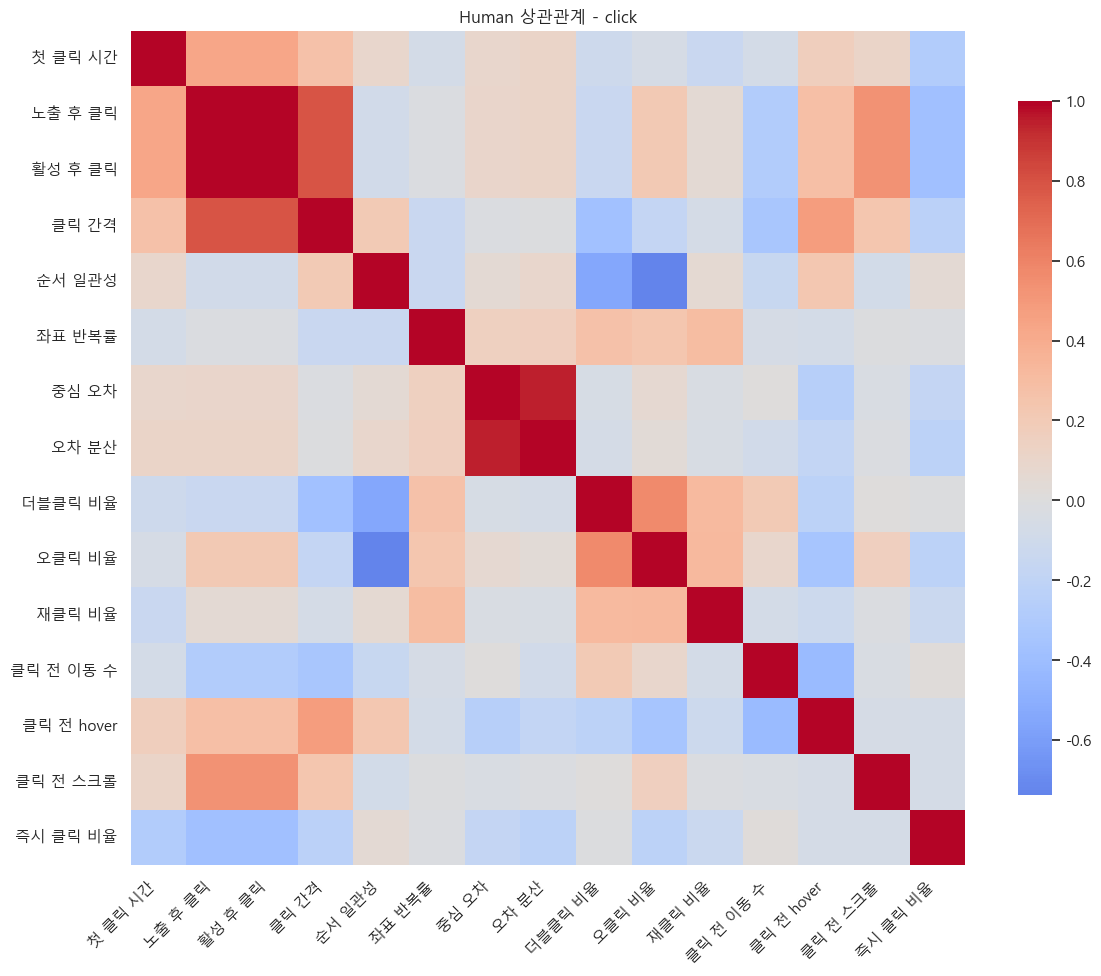

,feature_a,feature_b,corr,abs_corr
0,노출 후 클릭,활성 후 클릭,1.000000,1.000000
1,중심 오차,오차 분산,0.944216,0.944216
2,노출 후 클릭,클릭 간격,0.792852,0.792852
3,활성 후 클릭,클릭 간격,0.792852,0.792852
4,순서 일관성,오클릭 비율,-0.738769,0.738769
5,더블클릭 비율,오클릭 비율,0.565939,0.565939
6,순서 일관성,더블클릭 비율,-0.550859,0.550859
7,노출 후 클릭,클릭 전 스크롤,0.533622,0.533622
8,활성 후 클릭,클릭 전 스크롤,0.533622,0.533622
9,클릭 간격,클릭 전 hover,0.479663,0.479663


,cluster_id,rank,feature
0,1,2,노출 후 클릭
1,1,3,활성 후 클릭
2,2,8,중심 오차
3,2,999,오차 분산


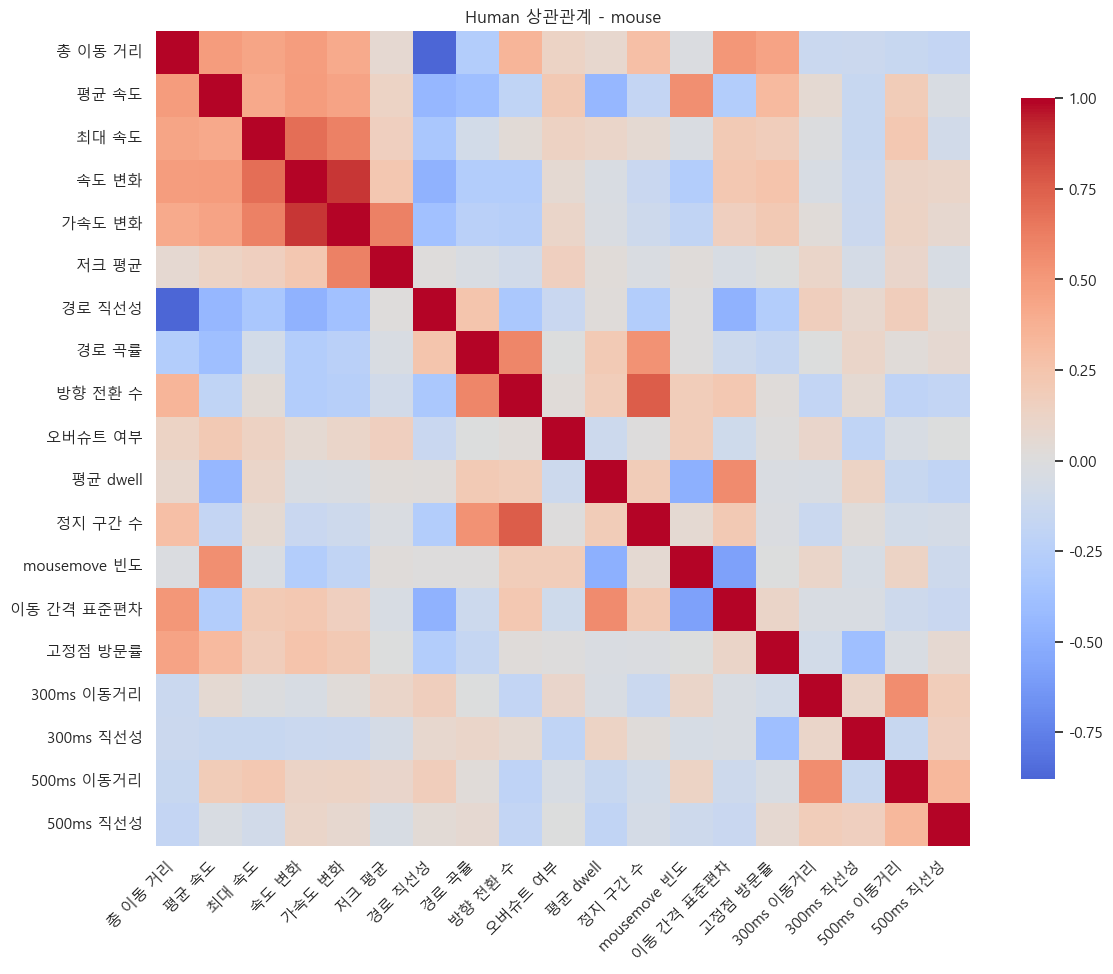

,feature_a,feature_b,corr,abs_corr
0,속도 변화,가속도 변화,0.895988,0.895988
1,총 이동 거리,경로 직선성,-0.877631,0.877631
2,방향 전환 수,정지 구간 수,0.761711,0.761711
3,최대 속도,속도 변화,0.690926,0.690926
4,최대 속도,가속도 변화,0.617103,0.617103
5,가속도 변화,저크 평균,0.615135,0.615135
6,경로 곡률,방향 전환 수,0.584901,0.584901
7,mousemove 빈도,이동 간격 표준편차,-0.583961,0.583961
8,평균 dwell,이동 간격 표준편차,0.563061,0.563061
9,300ms 이동거리,500ms 이동거리,0.558470,0.558470


no clusters (|corr|>=0.9) for mouse


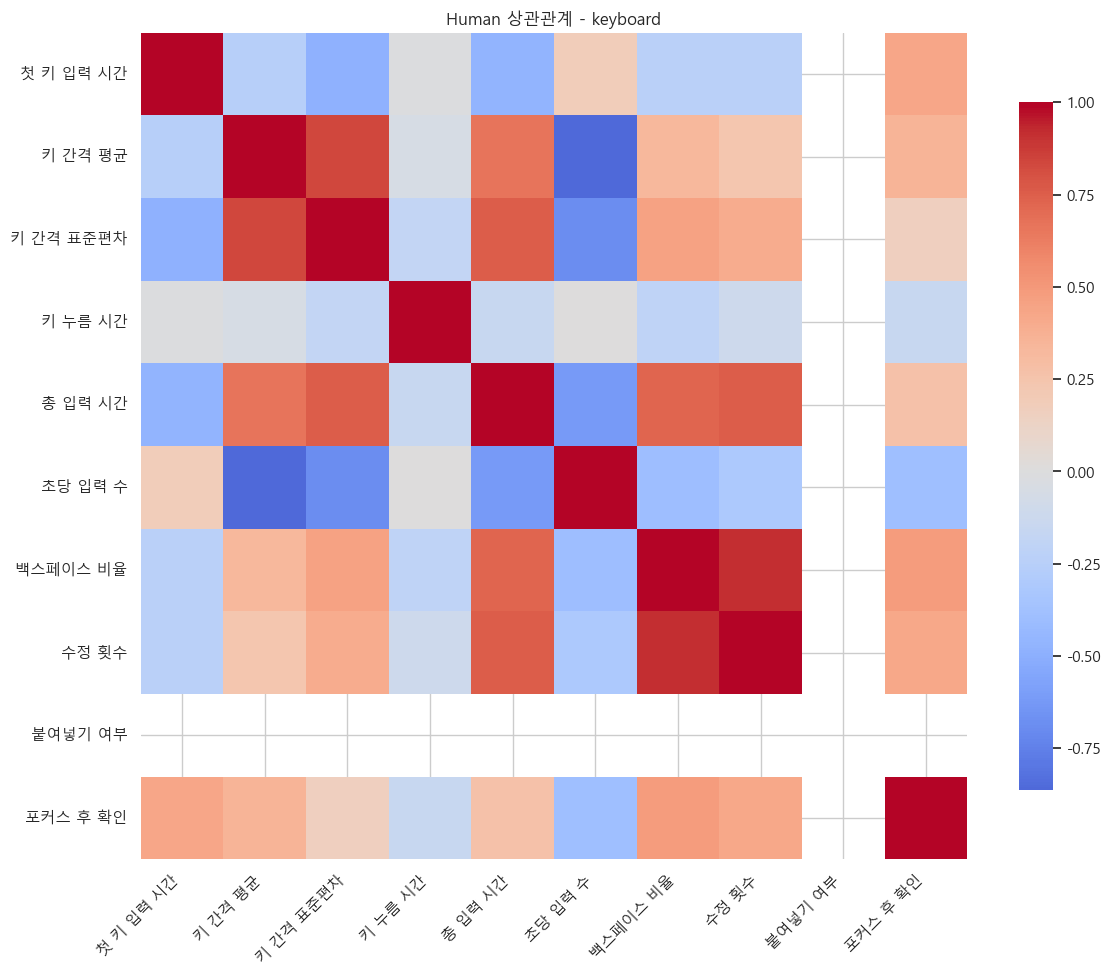

,feature_a,feature_b,corr,abs_corr
0,백스페이스 비율,수정 횟수,0.914276,0.914276
1,키 간격 평균,초당 입력 수,-0.862551,0.862551
2,키 간격 평균,키 간격 표준편차,0.835410,0.835410
3,키 간격 표준편차,총 입력 시간,0.759294,0.759294
4,총 입력 시간,수정 횟수,0.753920,0.753920
5,총 입력 시간,백스페이스 비율,0.726060,0.726060
6,키 간격 표준편차,초당 입력 수,-0.688382,0.688382
7,키 간격 평균,총 입력 시간,0.666109,0.666109
8,총 입력 시간,초당 입력 수,-0.615616,0.615616
9,첫 키 입력 시간,키 간격 표준편차,-0.491249,0.491249


,cluster_id,rank,feature
0,1,4,백스페이스 비율
1,1,5,수정 횟수


In [82]:
# 상관관계(한글 라벨만) + |corr|>=0.90 클러스터(중요 feature 먼저)
TOP_N_PAIRS = 30
CORR_THRESHOLD = 0.90

# 경험 기반 중요도(rank): 숫자가 작을수록 중요
FEATURE_RANK = {
    "click": {
        "immediate_post_render_click_rate": 1,
        "time_from_element_visible_to_click_ms": 2,
        "time_from_element_clickable_to_click_ms": 3,
        "inter_click_interval_ms": 4,
        "pre_click_hover_time_ms": 5,
        "misclick_rate": 6,
        "reclick_rate": 7,
        "click_offset_from_element_center_px": 8,
        "click_position_repeat_rate": 9,
        "click_sequence_consistency_score": 10,
    },
    "mouse": {
        "mousemove_event_rate": 1,
        "mouse_speed_change_mean": 2,
        "mouse_path_straightness_score": 3,
        "mouse_direction_change_count": 4,
        "mouse_overshoot_flag": 5,
        "inter_element_move_interval_std_ms": 6,
        "edge_or_fixed_point_visit_rate": 7,
        "mouse_total_travel_distance_px": 8,
        "pre_click_path_300ms_total_distance_px": 9,
        "pre_click_path_300ms_straightness": 10,
    },
    "keyboard": {
        "paste_flag": 1,
        "inter_key_interval_ms_std": 2,
        "inter_key_interval_ms_mean": 3,
        "backspace_rate": 4,
        "correction_count": 5,
        "keydown_to_keyup_ms_mean": 6,
        "typing_speed_cps": 7,
        "typing_total_duration_ms": 8,
        "time_to_first_keydown_ms": 9,
        "focus_to_submit_ms": 10,
    },
}


def _rank(group: str, feature: str) -> int:
    return int(FEATURE_RANK.get(group, {}).get(feature, 999))


def _ko(feature: str) -> str:
    # 한글명만 보여주기(매핑 없으면 feature명을 그대로)
    return FEATURE_NAME_KO.get(feature, feature)


def _clusters_by_threshold(cols: list[str], corr: pd.DataFrame, threshold: float) -> list[list[str]]:
    adj: dict[str, set[str]] = {c: set() for c in cols}
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            v = corr.loc[a, b]
            if pd.isna(v):
                continue
            if abs(float(v)) >= threshold:
                adj[a].add(b)
                adj[b].add(a)

    seen: set[str] = set()
    comps: list[list[str]] = []
    for node in cols:
        if node in seen:
            continue
        stack = [node]
        comp: list[str] = []
        while stack:
            x = stack.pop()
            if x in seen:
                continue
            seen.add(x)
            comp.append(x)
            stack.extend(list(adj[x] - seen))
        if len(comp) >= 2:
            comps.append(comp)
    return comps


for group_name in ["click", "mouse", "keyboard"]:
    frame = group_frames[group_name]
    cols = list(frame.columns)
    if len(cols) < 2:
        print("skip corr:", group_name)
        continue

    corr = frame.corr(numeric_only=True)

    # Heatmap: 한글 라벨만
    corr_ko = corr.copy()
    corr_ko.index = [_ko(c) for c in corr_ko.index]
    corr_ko.columns = [_ko(c) for c in corr_ko.columns]

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_ko, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
    plt.title(f"Human 상관관계 - {group_name}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Pair Top-N (한글만)
    pairs = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            v = corr.loc[a, b]
            if pd.isna(v):
                continue
            pairs.append({"feature_a": _ko(a), "feature_b": _ko(b), "corr": float(v), "abs_corr": float(abs(v))})

    pairs_df = pd.DataFrame(pairs).sort_values("abs_corr", ascending=False).reset_index(drop=True)
    display(pairs_df.head(TOP_N_PAIRS))

    # |corr|>=threshold 클러스터
    comps = _clusters_by_threshold(cols, corr, CORR_THRESHOLD)
    cluster_rows = []
    for cid, comp in enumerate(comps, start=1):
        ordered = sorted(comp, key=lambda f: (_rank(group_name, f), _ko(f)))
        for f in ordered:
            cluster_rows.append({"cluster_id": cid, "rank": _rank(group_name, f), "feature": _ko(f)})

    if cluster_rows:
        clusters_df = (
            pd.DataFrame(cluster_rows)
            .sort_values(["cluster_id", "rank", "feature"], ascending=[True, True, True])
            .reset_index(drop=True)
        )
        display(clusters_df)
    else:
        print(f"no clusters (|corr|>={CORR_THRESHOLD}) for", group_name)
